Install & Import Libraries

In [2]:
# Install if missing (safe to run)
!pip -q install seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, f1_score, accuracy_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

print("✅ Libraries Loaded")


✅ Libraries Loaded


Upload Dataset

In [3]:
from google.colab import files

uploaded = files.upload()   # upload WA_Fn-UseC_-Telco-Customer-Churn.csv


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


Load Data

In [4]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Dataset Info + Missing Values

In [5]:
df.info()

print("\nMissing Values:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Cleaning

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

print("Cleaning Done ✅")


Cleaning Done ✅


Target Distribution Plot

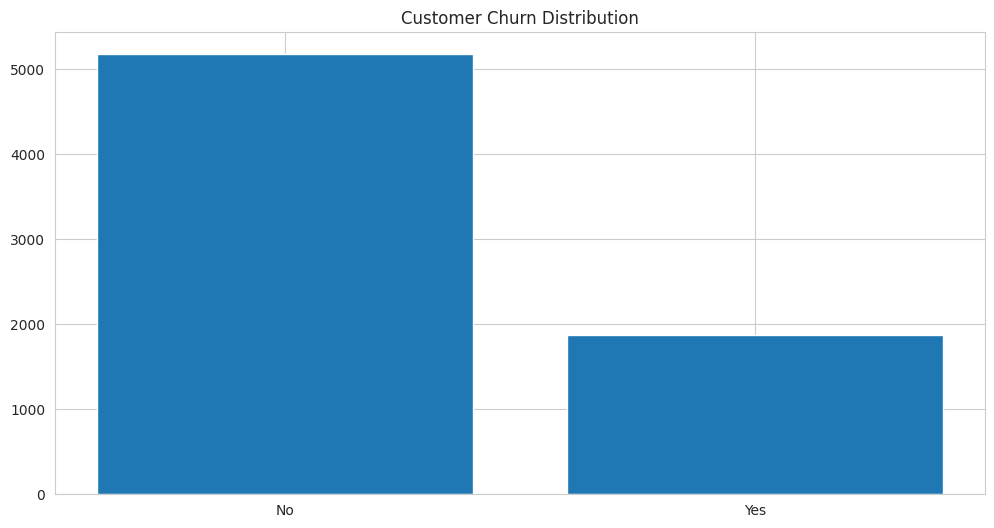

Churn Rate: 0.2653698707936959


In [7]:
counts = df['Churn'].value_counts()

plt.bar(counts.index, counts.values)
plt.title("Customer Churn Distribution")
plt.show()

print("Churn Rate:", counts['Yes']/len(df))


Numerical Feature Distributions

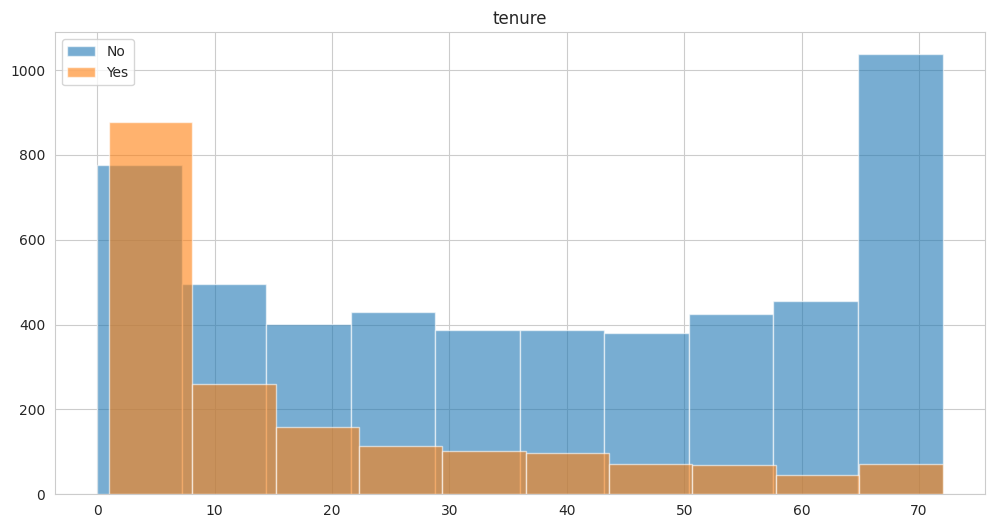

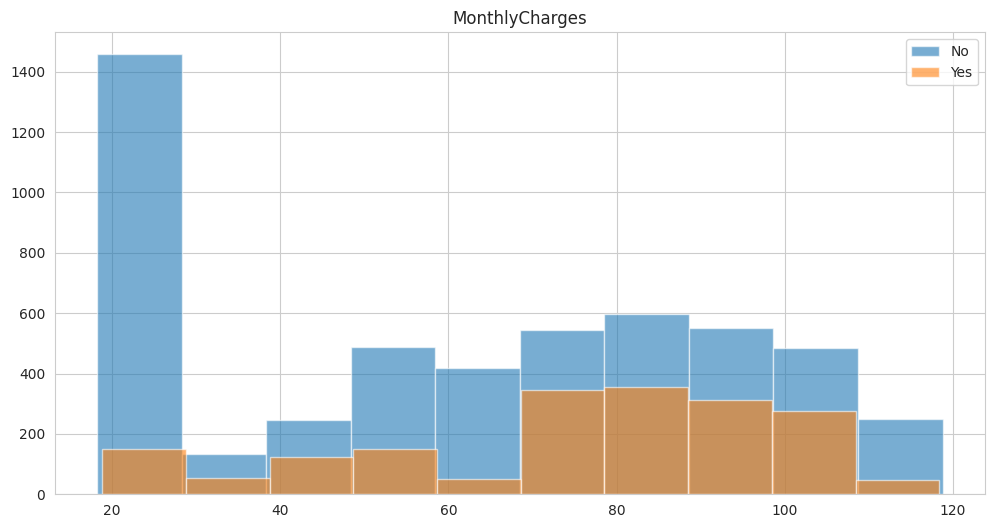

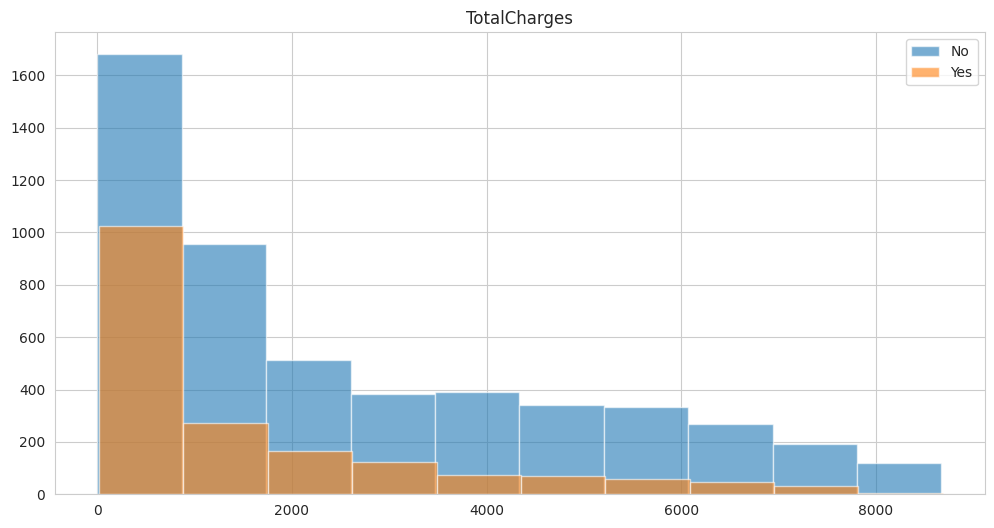

In [8]:
num_cols = ['tenure','MonthlyCharges','TotalCharges']

for col in num_cols:
    plt.figure()
    for label in ['No','Yes']:
        plt.hist(df[df['Churn']==label][col], alpha=0.6, label=label)
    plt.legend()
    plt.title(col)
    plt.show()


Categorical vs Churn

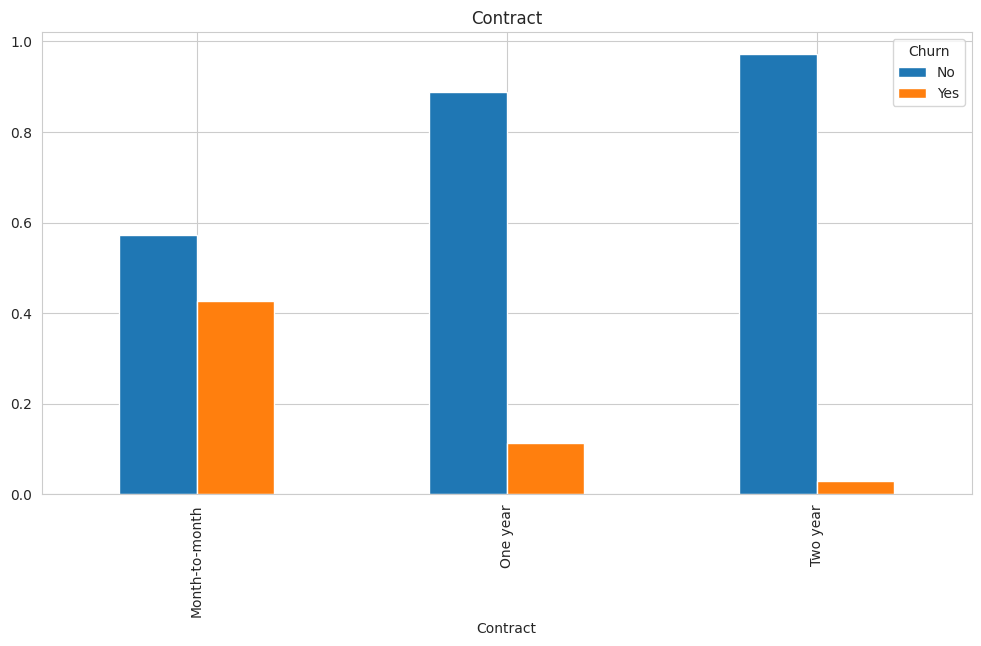

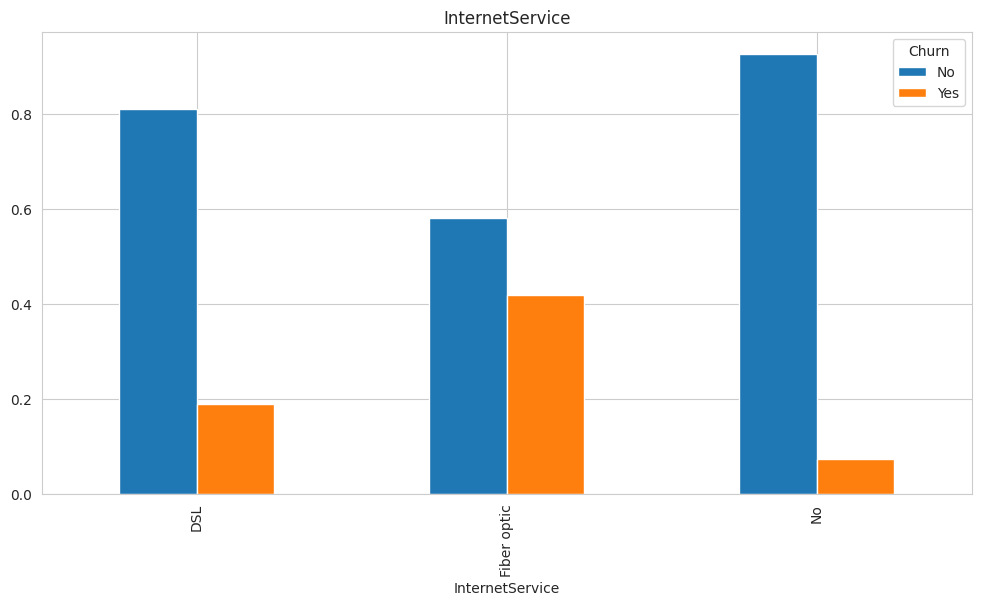

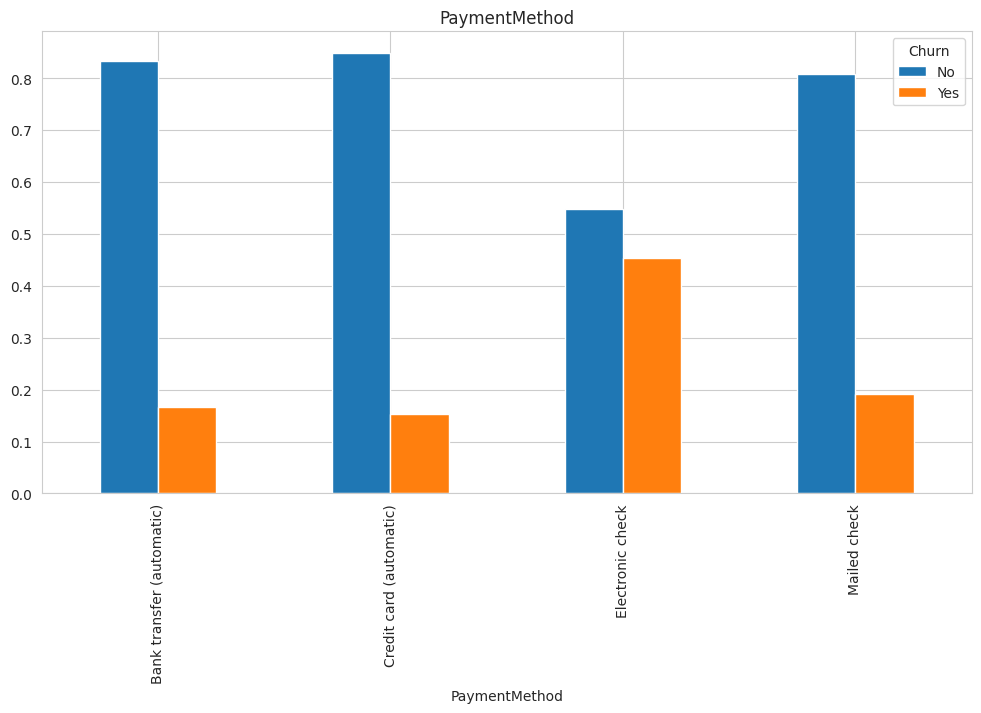

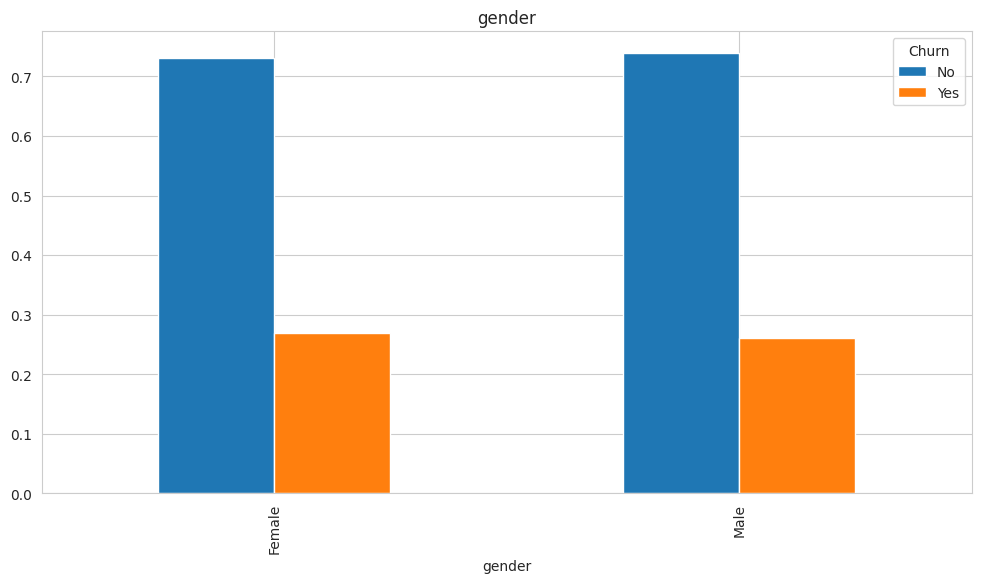

In [9]:
cats = ['Contract','InternetService','PaymentMethod','gender']

for col in cats:
    pd.crosstab(df[col], df['Churn'], normalize='index').plot(kind='bar')
    plt.title(col)
    plt.show()


Correlation Heatmap

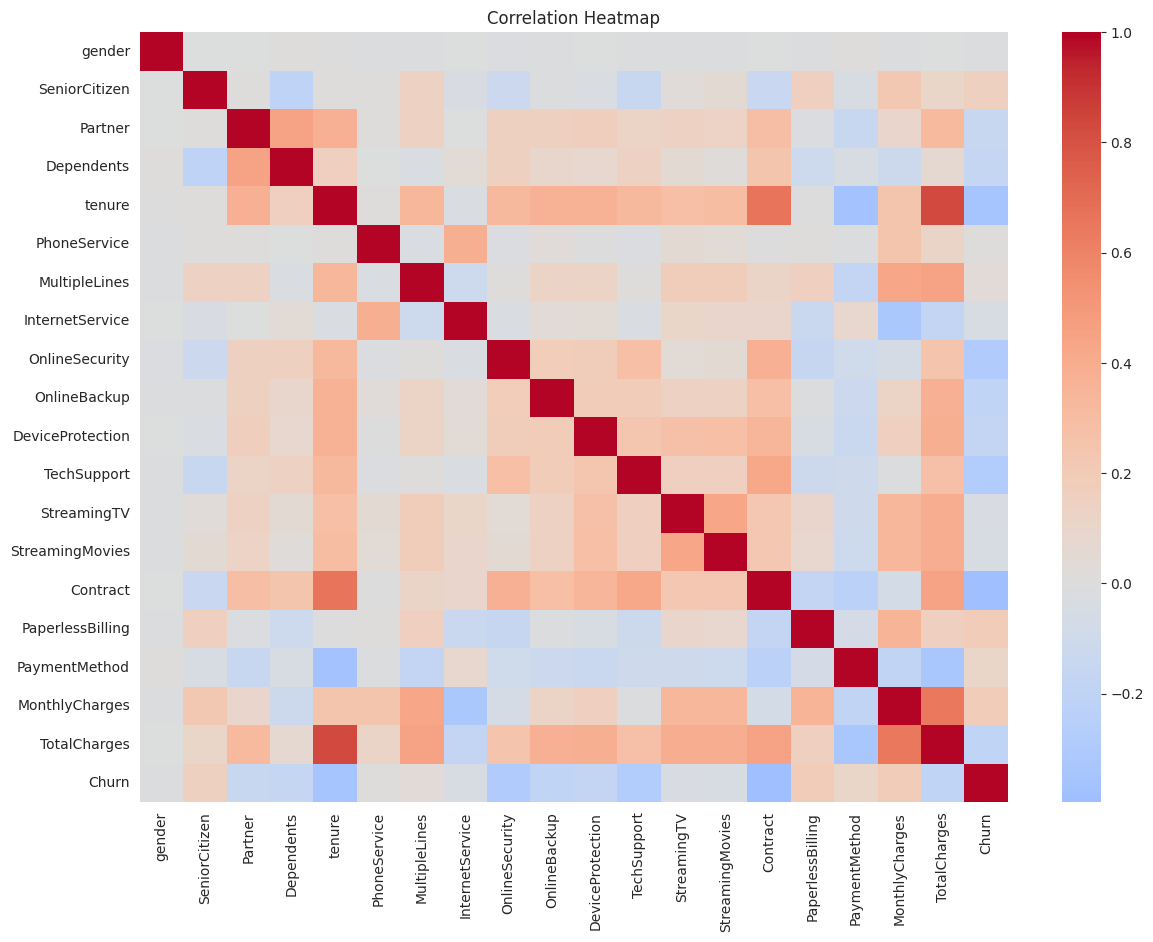

In [10]:
df_encoded = df.copy()

# Drop ID column first (VERY IMPORTANT)
df_encoded = df_encoded.drop('customerID', axis=1)

# Encode all object columns
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

plt.figure(figsize=(14,10))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()


Feature Engineering

In [11]:
df_model = df.drop('customerID', axis=1)

df_model['Churn'] = df_model['Churn'].map({'Yes':1,'No':0})

binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling']

for col in binary_cols:
    df_model[col] = df_model[col].map({'Yes':1,'No':0,'Male':1,'Female':0})

multi_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
              'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
              'Contract','PaymentMethod']

df_model = pd.get_dummies(df_model, columns=multi_cols, drop_first=True)

df_model.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


Train Test Split + Scaling

In [12]:
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("📊 DATA SPLIT SUMMARY")
print("-"*40)
print(f"Total samples   : {len(X)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples : {len(X_test)}")

print("\nChurn distribution:")
print(f"Train churn rate: {y_train.mean():.2%}")
print(f"Test churn rate : {y_test.mean():.2%}")

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Split + Scaling Done")


📊 DATA SPLIT SUMMARY
----------------------------------------
Total samples   : 7043
Training samples: 5634
Testing samples : 1409

Churn distribution:
Train churn rate: 26.54%
Test churn rate : 26.54%

✅ Split + Scaling Done


Train Multiple Models

In [20]:
# models = {
#     'Logistic Regression': LogisticRegression(max_iter=1000),
#     'Decision Tree': DecisionTreeClassifier(),
#     'Random Forest': RandomForestClassifier(),
#     'Gradient Boosting': GradientBoostingClassifier(),
#     'SVM': SVC(probability=True)
# }

# results = {}

# for name, model in models.items():
#     if name == 'SVM':
#         model.fit(X_train_scaled, y_train)
#         pred = model.predict(X_test_scaled)
#         proba = model.predict_proba(X_test_scaled)[:,1]
#     else:
#         model.fit(X_train, y_train)
#         pred = model.predict(X_test)
#         proba = model.predict_proba(X_test)[:,1]

#     results[name] = {
#         "accuracy": accuracy_score(y_test,pred),
#         "f1": f1_score(y_test,pred),
#         "roc": roc_auc_score(y_test,proba),
#         "model": model,
#         "pred": pred,
#         "proba": proba
#     }

#     print(name, results[name])
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'SVM': SVC(probability=True)
}

results = []
stored_models = {}

for name, model in models.items():

    # Train
    if name == 'SVM':
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
        proba = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        proba = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, pred)
    f1  = f1_score(y_test, pred)
    roc = roc_auc_score(y_test, proba)

    # store for later use
    stored_models[name] = {
        "model": model,
        "pred": pred,
        "proba": proba
    }

    results.append([name, acc, f1, roc])


# -----------------------------
# Convert to clean table
# -----------------------------
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "F1 Score", "ROC AUC"]
)

results_df = results_df.sort_values("ROC AUC", ascending=False)

results_df.style.format({
    "Accuracy": "{:.4f}",
    "F1 Score": "{:.4f}",
    "ROC AUC": "{:.4f}"
})


,Model,Accuracy,F1 Score,ROC AUC
0,Logistic Regression,0.8055,0.6040,0.8427
3,Gradient Boosting,0.7984,0.5723,0.8422
2,Random Forest,0.7871,0.5562,0.8260
4,SVM,0.7928,0.5562,0.7961
1,Decision Tree,0.7346,0.4905,0.6532


Best Model Evaluation

In [14]:
best = max(results, key=lambda x: results[x]['roc'])

print("Best Model:", best)

print(classification_report(y_test, results[best]['pred']))


Best Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



Confusion Matrix

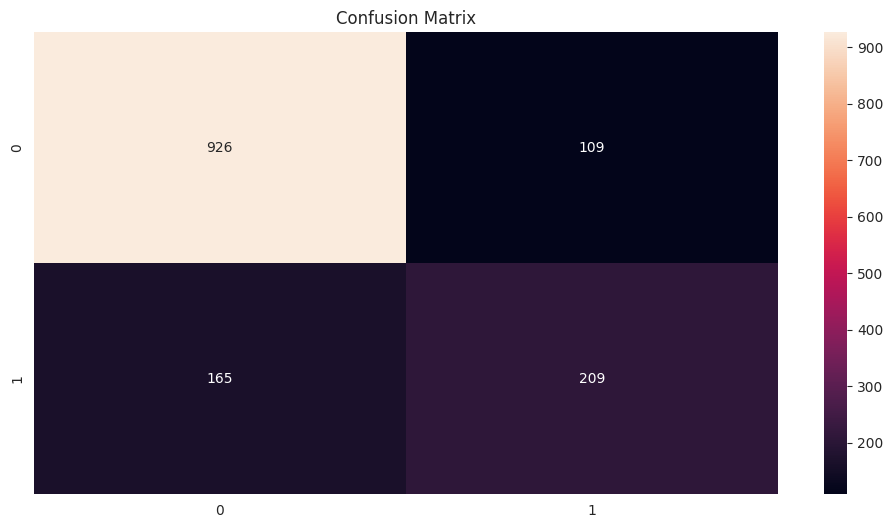

In [15]:
sns.heatmap(confusion_matrix(y_test, results[best]['pred']),
            annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()


ROC Curves

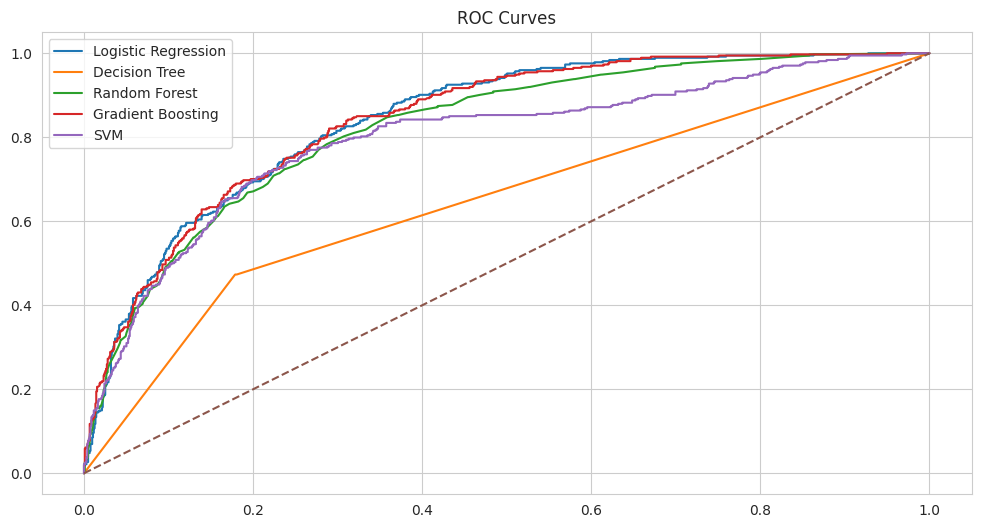

In [16]:
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['proba'])
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curves")
plt.show()


Model Comparison

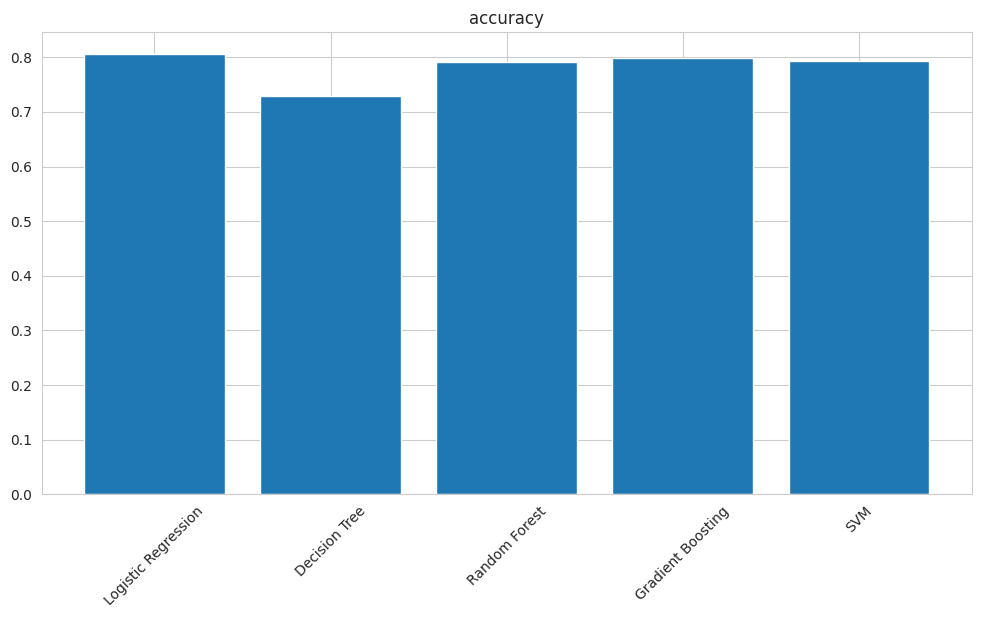

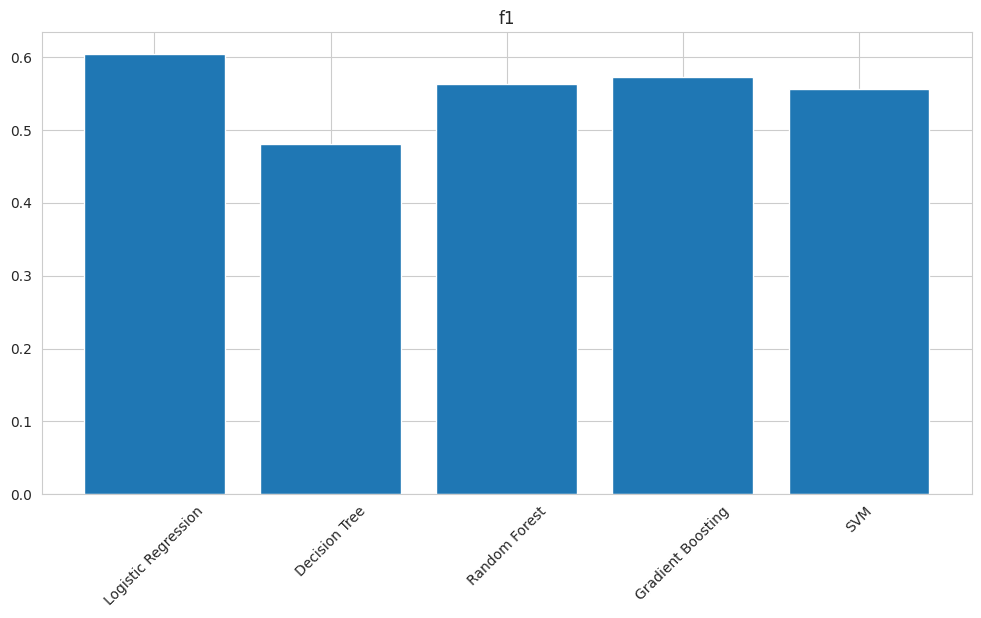

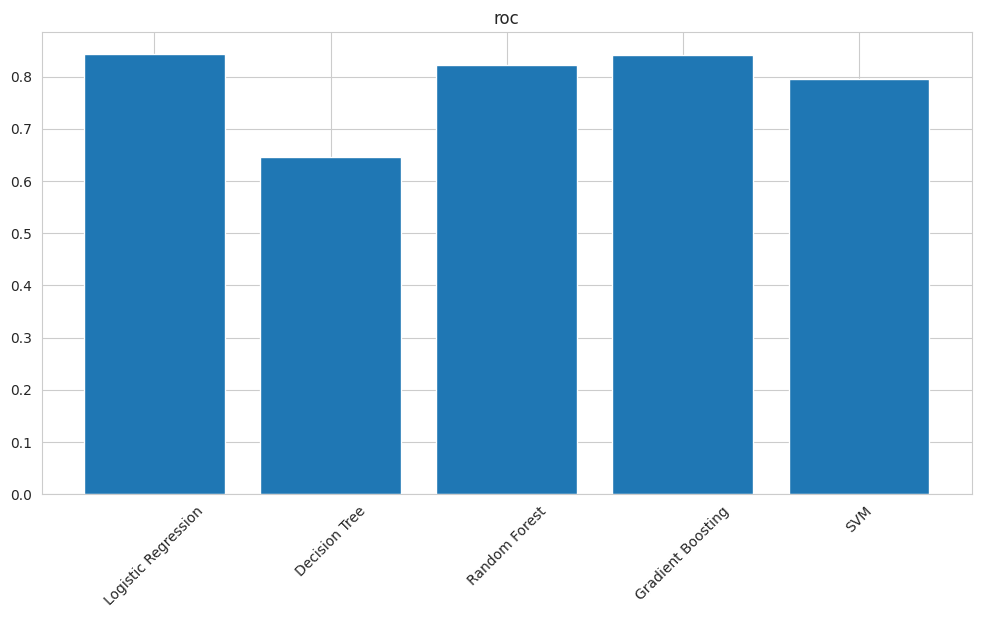

In [17]:
for metric in ['accuracy','f1','roc']:
    vals = [results[m][metric] for m in results]
    plt.bar(results.keys(), vals)
    plt.title(metric)
    plt.xticks(rotation=45)
    plt.show()


Hyperparameter Tuning (Random Forest Example)

In [18]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[10,15]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, scoring='roc_auc', cv=5)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)


Best Params: {'max_depth': 10, 'n_estimators': 200}
Best Score: 0.8413898446769437


Final Summary

In [19]:
print("Dataset size:", len(df))
print("Churn Rate:", df['Churn'].value_counts()['Yes']/len(df))
print("Best Model:", best)
print("ROC AUC:", results[best]['roc'])


Dataset size: 7043
Churn Rate: 0.2653698707936959
Best Model: Logistic Regression
ROC AUC: 0.8426954971712005
